In [1]:
import os
import tempfile

import kornia.augmentation as K
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

from torchgeo.datasets import EuroSAT
from torchgeo.models import ResNet18_Weights, resnet18

torch.manual_seed(0)

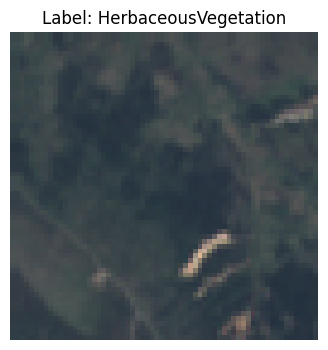

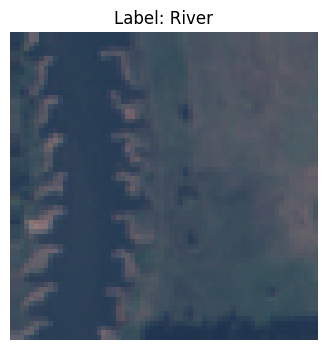

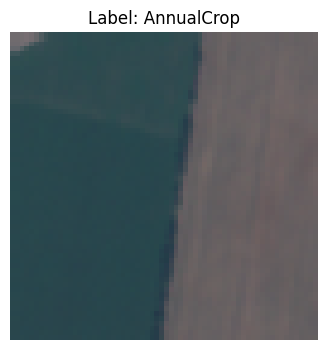

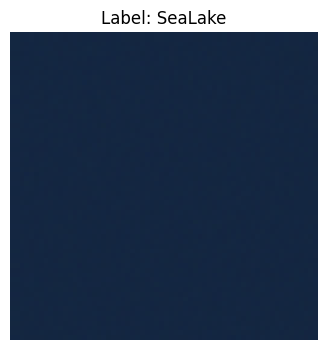

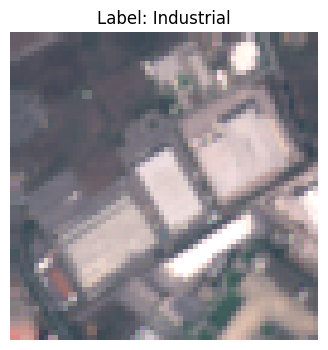

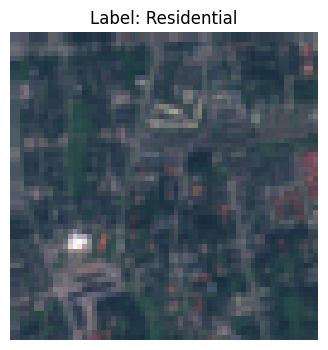

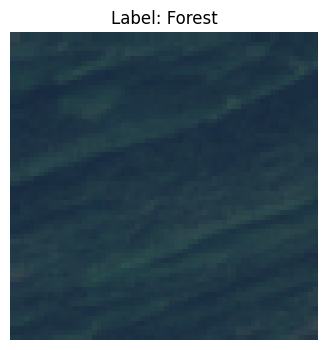

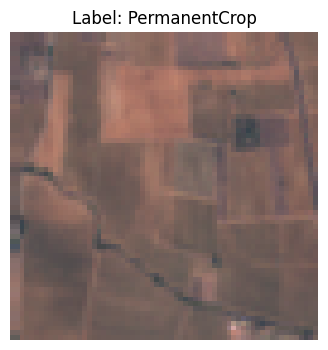

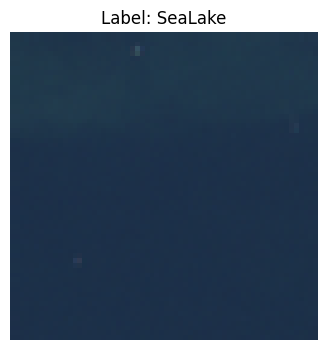

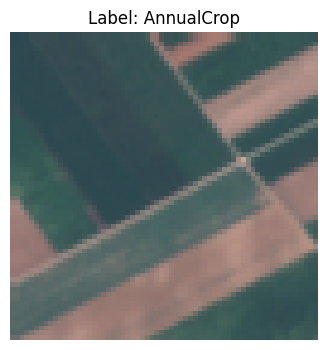

In [2]:
root = os.path.join(tempfile.gettempdir(), 'pytorch')
dataset = EuroSAT(root, download=True)

for i in torch.randint(len(dataset), (10,)):
    sample = dataset[i]
    dataset.plot(sample)

In [3]:
train_dataset = EuroSAT(root, split='train')
val_dataset = EuroSAT(root, split='val', download=True)
test_dataset = EuroSAT(root, split='test', download=True)

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=64, num_workers=4, pin_memory=True, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, num_workers=4, pin_memory=True, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=256, num_workers=4, pin_memory=True, shuffle=False)

In [5]:
preprocess = K.Normalize(0, 10000)
augment = K.ImageSequential(K.RandomHorizontalFlip(), K.RandomVerticalFlip())

In [6]:
model = resnet18(ResNet18_Weights.SENTINEL2_ALL_MOCO)

In [7]:
loss_fn = nn.CrossEntropyLoss()

In [8]:
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [10]:
print(device)

cuda


In [11]:
def train(dataloader):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x = batch['image'].to(device)
        y = batch['label'].to(device)

        # Forward pass
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f'Loss: {total_loss:.2f}')

In [12]:
def evaluate(dataloader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in dataloader:
            x = batch['image'].to(device)
            y = batch['label'].to(device)

            # Forward pass
            y_hat = model(x)
            correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()

    correct /= len(dataloader.dataset)
    print(f'Accuracy: {correct:.0%}')

In [13]:
epochs = 3

for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    train(train_dataloader)
    evaluate(val_dataloader)

Epoch: 0
Loss: 1475.79
Accuracy: 76%
Epoch: 1
Loss: 500.91
Accuracy: 93%
Epoch: 2
Loss: 83.18
Accuracy: 96%


In [14]:
evaluate(test_dataloader)
torch.save(model.state_dict(), "eurosat_resnet18.pth")

Accuracy: 96%


In [16]:
# Maybe something like:
print(type(model))
for name, param in model.named_parameters():
    if 'fc' in name or 'classifier' in name or 'head' in name:
        print(f"{name}: {param.shape}")

<class 'timm.models.resnet.ResNet'>
fc.weight: torch.Size([1000, 512])
fc.bias: torch.Size([1000])


In [17]:
print(dataset.all_band_names)

('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


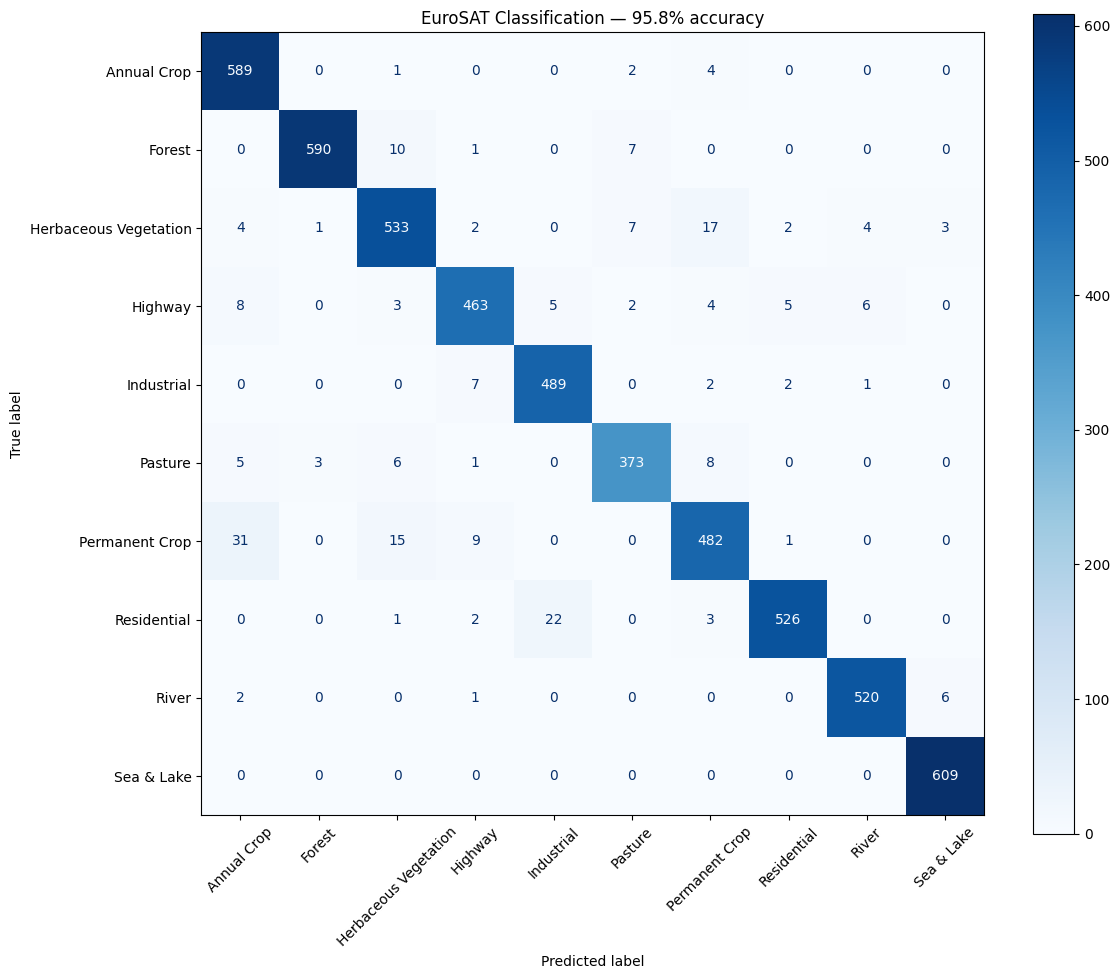

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Class names for EuroSAT
class_names = [
    "Annual Crop", "Forest", "Herbaceous Vegetation",
    "Highway", "Industrial", "Pasture",
    "Permanent Crop", "Residential", "River", "Sea & Lake"
]

# Collect predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        images = batch["image"].to(device)
        labels = batch["label"]

        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
ax.set_title(f"EuroSAT Classification — {(all_preds == all_labels).mean():.1%} accuracy")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

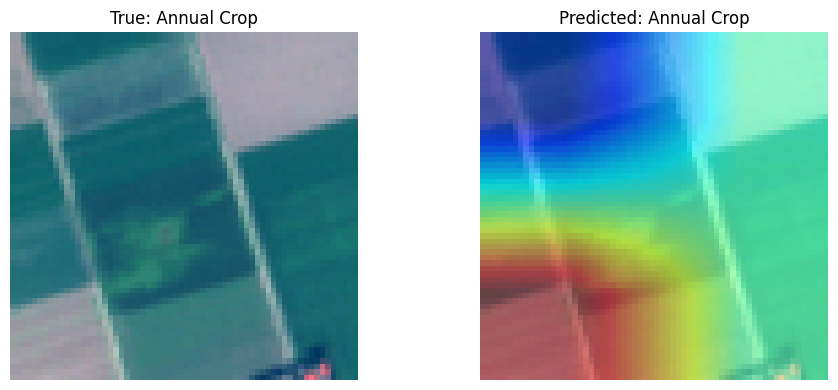

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

# Point GradCAM at the last conv layer of ResNet-18
# (adjust 'model' to whatever your variable is called)
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# Grab a batch from your test set
batch = next(iter(test_dataloader))
images = batch["image"]
labels = batch["label"]

# Run GradCAM on one image
input_tensor = images[0].unsqueeze(0).to(device)  # add batch dimension
grayscale_cam = cam(input_tensor=input_tensor)  # shape: (1, H, W)
grayscale_cam = grayscale_cam[0]  # remove batch dimension

# Prepare the RGB image for overlay
# EuroSAT bands: take B04, B03, B02 (red, green, blue) — check your band ordering
# and normalize to [0, 1] for display
rgb = images[0][[3, 2, 1]].permute(1, 2, 0).numpy()  # CHW -> HWC
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # normalize to 0-1
rgb = rgb.astype(np.float32)

# Overlay heatmap on image
overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

# Plot side by side
pred = model(input_tensor).argmax(dim=1).item()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(rgb)
axes[0].set_title(f"True: {class_names[labels[0]]}")
axes[1].imshow(overlay)
axes[1].set_title(f"Predicted: {class_names[pred]}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("gradcam_example.png", dpi=150)
plt.show()

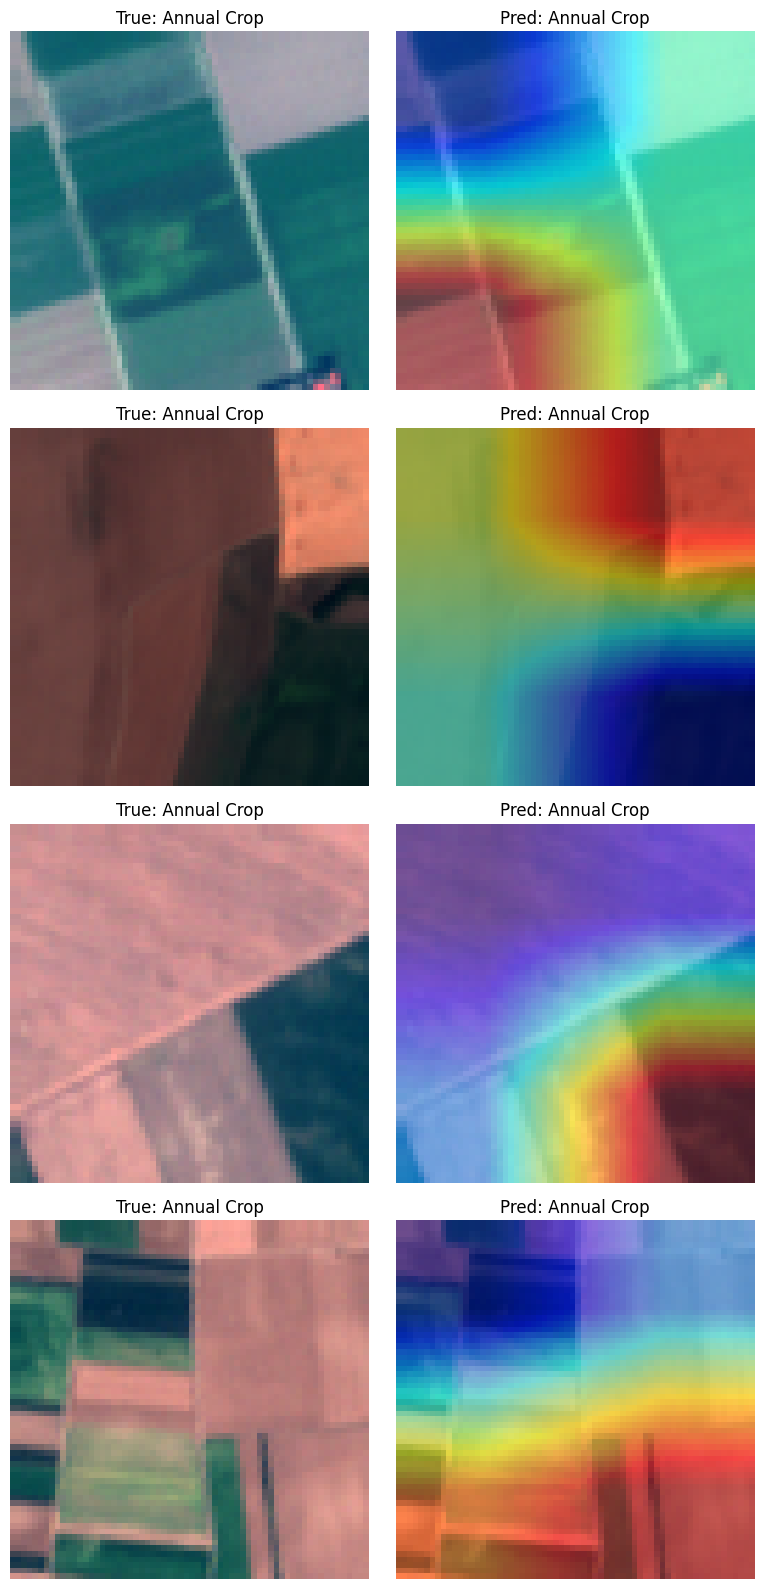

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for i in range(4):
    input_tensor = images[i].unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    pred = model(input_tensor).argmax(dim=1).item()
    
    rgb = images[i][[3, 2, 1]].permute(1, 2, 0).numpy()
    rgb = ((rgb - rgb.min()) / (rgb.max() - rgb.min())).astype(np.float32)
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)
    
    axes[i][0].imshow(rgb)
    axes[i][0].set_title(f"True: {class_names[labels[i]]}")
    axes[i][1].imshow(overlay)
    axes[i][1].set_title(f"Pred: {class_names[pred]}")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.savefig("gradcam_grid.png", dpi=150)
plt.show()